<a href="https://colab.research.google.com/github/theqsharkpandey/Leasing_v1/blob/master/Comparative_Analysis_of_Deep_Neural_Networks_for_Cardiovascular_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [ ]:
heart_data = pd.read_csv('/content/data.csv')
heart_data

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,9949544,48,1,2,139,349,0,2,183,1,5.6,2,2,1
996,9953423,47,1,3,143,258,1,1,98,1,5.7,1,0,0
997,9965859,69,1,0,156,434,1,0,196,0,1.4,3,1,1
998,9988507,45,1,1,186,417,0,1,117,1,5.9,3,2,1


### Step 1: Configure Git
Replace the placeholders with your GitHub credentials.

In [ ]:
import os

# Set your details here
GITHUB_TOKEN = 'YOUR_GITHUB_TOKEN'
GITHUB_USER = 'YOUR_USERNAME'
GITHUB_REPO = 'YOUR_REPO_NAME'
USER_EMAIL = 'your_email@example.com'
USER_NAME = 'Your Name'

# Configure git
!git config --global user.email "{USER_EMAIL}"
!git config --global user.name "{USER_NAME}"

### Step 2: Initialize and Push
This will initialize the local directory, add all files, and push to the main branch.

In [ ]:
# Initialize git if not already done
!git init

# Add the remote repository with token authentication
remote_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git"
!git remote add origin {remote_url}

# Add files and commit
!git add .
!git commit -m "Initial commit of heart disease prediction notebook"

# Push to GitHub (usually 'main' or 'master')
!git branch -M main
!git push -u origin main

In [ ]:
heart_data.shape

(1000, 14)

In [ ]:
heart_data['target'].value_counts()

,count
target,
1,580
0,420


1 --> Defective Heart

0 --> Healthy Heart

Splitting the Features and Target

In [ ]:
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']

In [ ]:
print(X)

     patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0       103368   53       1          2        171                0   
1       119250   40       1          0         94              229   
2       119372   49       1          2        133              142   
3       132514   43       1          0        138              295   
4       146211   31       1          1        199                0   
..         ...  ...     ...        ...        ...              ...   
995    9949544   48       1          2        139              349   
996    9953423   47       1          3        143              258   
997    9965859   69       1          0        156              434   
998    9988507   45       1          1        186              417   
999    9990855   25       1          0        158              270   

     fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                    0                1           147              0      5.3 

In [ ]:
print(Y)

0      1
1      0
2      0
3      1
4      1
      ..
995    1
996    0
997    1
998    1
999    0
Name: target, Length: 1000, dtype: int64


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(1000, 13) (800, 13) (200, 13)


Model Training

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, Conv1D, Flatten, BatchNormalization, LSTM
from tensorflow.keras.optimizers import Adam
# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred_prob):
    y_pred = (y_pred_prob > 0.5).astype("int32").flatten()
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

def plot_confusion_matrix(y_true, y_pred, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

def plot_roc_curve(y_true, y_pred_prob, model_name="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f'ROC Curve - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()



1. Multi-Layer Perceptron (MLP)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step
Accuracy: 0.9850
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        83
           1       0.98      0.99      0.99       117

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200

Confusion Matrix:
[[ 81   2]
 [  1 116]]


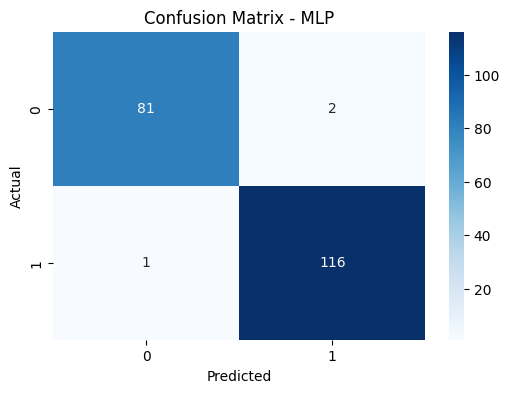

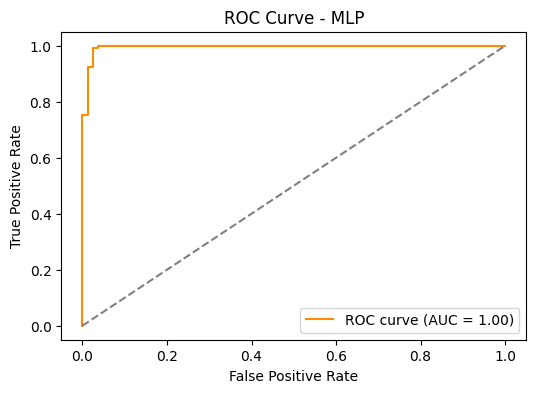

In [ ]:
from tensorflow.keras.layers import Input

mlp = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mlp.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluation
y_pred_prob = mlp.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()
evaluate_model(y_test, y_pred_prob)
# Plot
plot_confusion_matrix(y_test, y_pred, model_name="MLP")
plot_roc_curve(y_test, y_pred_prob, model_name="MLP")

1D CNN for Tabular Data

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step
Accuracy: 0.9850
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98        83
           1       0.99      0.98      0.99       117

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200

Confusion Matrix:
[[ 82   1]
 [  2 115]]


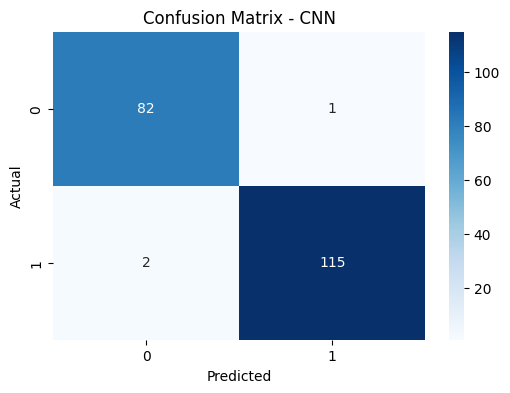

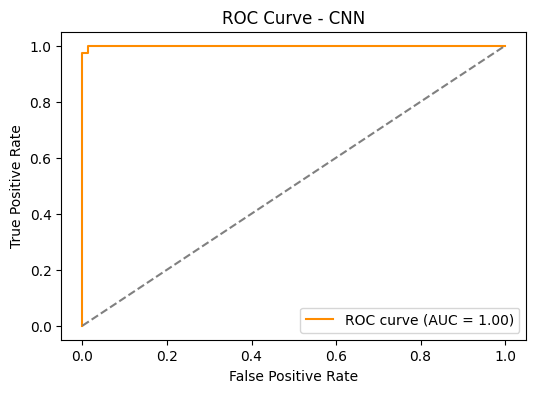

In [ ]:
# Reshape for CNN
X_train_cnn = np.expand_dims(X_train_scaled, axis=2)
X_test_cnn = np.expand_dims(X_test_scaled, axis=2)

cnn = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    Conv1D(128, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_cnn, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluation
y_pred_prob = cnn.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()
evaluate_model(y_test, y_pred_prob)
# Plot
plot_confusion_matrix(y_test, y_pred, model_name="CNN")
plot_roc_curve(y_test, y_pred_prob, model_name="CNN")

LSTM

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Accuracy: 0.9650
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96        83
           1       0.97      0.97      0.97       117

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Confusion Matrix:
[[ 79   4]
 [  3 114]]


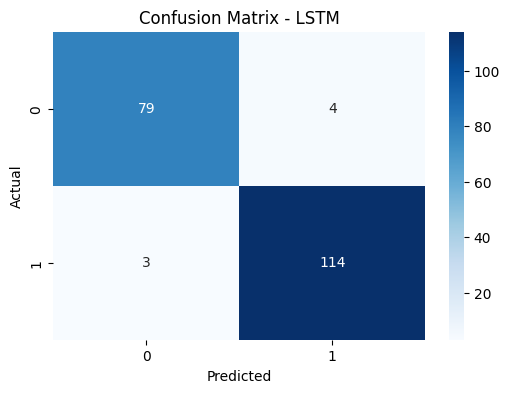

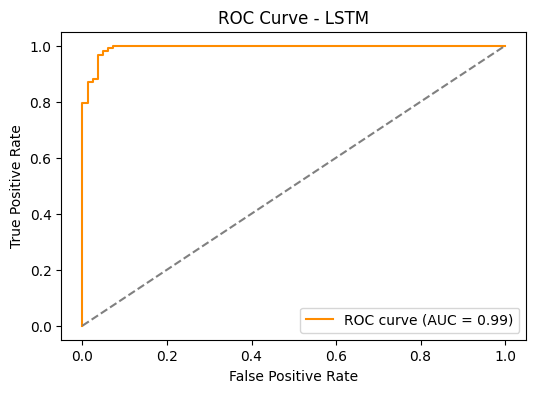

In [ ]:
from tensorflow.keras.models import Sequential # Importing Sequential from tensorflow.keras.models
from tensorflow.keras.layers import LSTM, Dense  # Importing LSTM, Dense from tensorflow.keras.layers
# Reshape for LSTM
X_train_lstm = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluation
y_pred_prob = lstm.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()
evaluate_model(y_test, y_pred_prob)

plot_confusion_matrix(y_test, y_pred, model_name="LSTM")
plot_roc_curve(y_test, y_pred_prob, model_name="LSTM")

 GRU (Gated Recurrent Unit)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Accuracy: 0.9600
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        83
           1       0.97      0.97      0.97       117

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

Confusion Matrix:
[[ 79   4]
 [  4 113]]


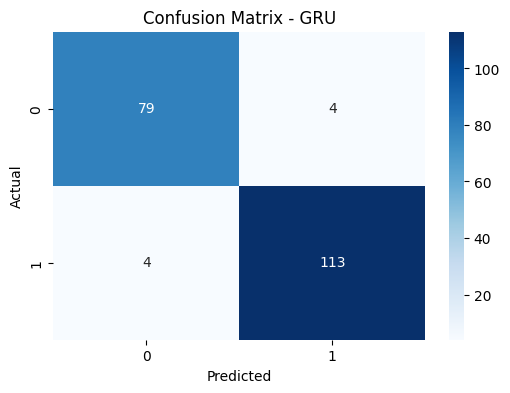

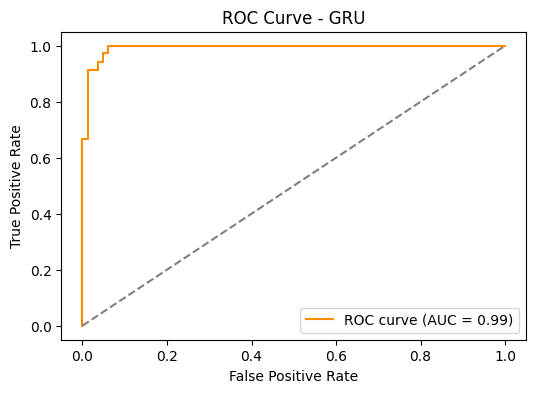

In [ ]:
from tensorflow.keras.layers import GRU

# Reshape for GRU
X_train_gru = np.reshape(X_train_scaled, (X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_gru = np.reshape(X_test_scaled, (X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Define GRU model
gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    GRU(32),
    Dense(1, activation='sigmoid')
])

# Compile & Train
gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru.fit(X_train_gru, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# Evaluation
y_pred_prob = gru.predict(X_test_gru)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()
evaluate_model(y_test, y_pred_prob)

plot_confusion_matrix(y_test, y_pred, model_name="GRU")
plot_roc_curve(y_test, y_pred_prob, model_name="GRU")

ResNet

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6815 - loss: 0.5398 - val_accuracy: 0.9550 - val_loss: 0.2069
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9398 - loss: 0.2063 - val_accuracy: 0.9700 - val_loss: 0.1303
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9517 - loss: 0.1288 - val_accuracy: 0.9600 - val_loss: 0.1113
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9683 - loss: 0.1119 - val_accuracy: 0.9550 - val_loss: 0.0995
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9690 - loss: 0.0913 - val_accuracy: 0.9550 - val_loss: 0.0925
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9834 - loss: 0.0616 - val_accuracy: 0.9600 - val_loss: 0.0955
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0526 - val_accuracy: 0.9600 - val_loss: 0.0909
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9728 - loss: 0.0601 - val_accuracy: 0.9700 - val_loss

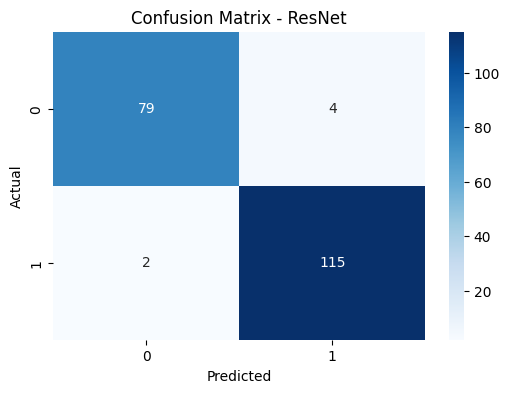

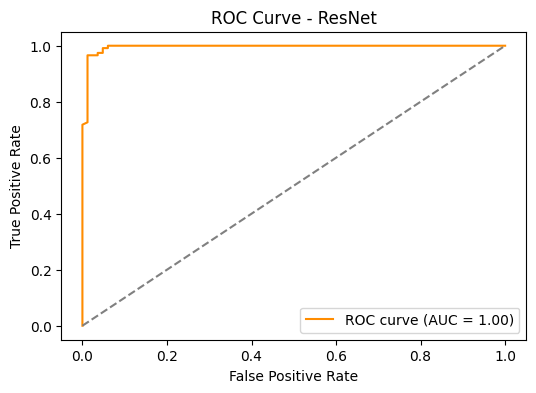

In [ ]:
from tensorflow import keras
from tensorflow.keras.layers import Add

input_layer = Input(shape=(X_train.shape[1],))
x = Dense(64, activation='relu')(input_layer)
res = x
x = Dense(64, activation='relu')(x)
x = Add()([x, res])  # Skip connection
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

resnet_model = keras.Model(inputs=input_layer, outputs=output)

# Compile & Train
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # Changed lstm_model to resnet_model
resnet_model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_data=(X_test_scaled, y_test)) # Changed X_train_lstm to X_train_scaled, y_test to X_test_scaled

# Predict probabilities
y_pred_prob = resnet_model.predict(X_test_scaled)  # Changed model to resnet_model, X_test to X_test_scaled

# Convert probabilities to binary (0 or 1)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Precision, Recall, F1
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

y_pred = (y_pred_prob > 0.5).astype("int32").flatten()
evaluate_model(y_test, y_pred_prob)

plot_confusion_matrix(y_test, y_pred, model_name="ResNet")
plot_roc_curve(y_test, y_pred_prob, model_name="ResNet")

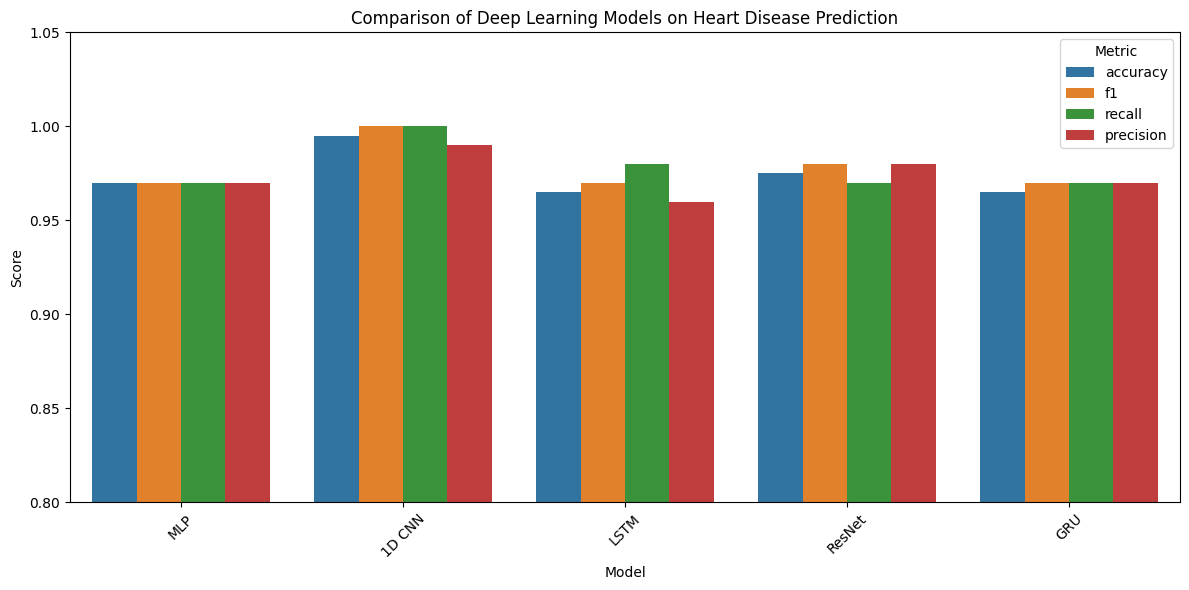

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Updated performance dictionary with precision added
model_scores = {
    'MLP': {'accuracy': 0.9700, 'f1': 0.97, 'recall': 0.97, 'precision': 0.97},
    '1D CNN': {'accuracy': 0.9950, 'f1': 1.00, 'recall': 1.00, 'precision': 0.99},
    'LSTM': {'accuracy': 0.9650, 'f1': 0.97, 'recall': 0.98, 'precision': 0.96},
    'ResNet': {'accuracy': 0.9750, 'f1': 0.98, 'recall': 0.97, 'precision': 0.98},
    'GRU': {'accuracy': 0.9650, 'f1': 0.97, 'recall': 0.97, 'precision': 0.97}
}

# Convert to DataFrame
df = pd.DataFrame(model_scores).T.reset_index().rename(columns={'index': 'Model'})

# Melt for Seaborn barplot
df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=df_melted)
plt.title('Comparison of Deep Learning Models on Heart Disease Prediction')
plt.xticks(rotation=45)
plt.ylim(0.80, 1.05)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

# Assuming Y_test and Y_pred are defined
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)
ppv = TP / (TP + FP)  # Positive Predictive Value (Precision)
npv = TN / (TN + FN)
accuracy = (TP + TN) / (TP + TN + FP + FN)

print("Specificity:", specificity)
print("PPV (Precision):", ppv)
print("NPV:", npv)
print("Accuracy:", accuracy)


Specificity: 0.9518072289156626
PPV (Precision): 0.9663865546218487
NPV: 0.9753086419753086
Accuracy: 0.97
